# 1. Import Libraries

In [2]:
!pip install transformers scikit-learn datasets 'accelerate>=1.1.0'
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


# 2. Load Model

In [3]:
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7361.32it/s]


# 3. Prepare Dataset

In [5]:
df = pd.read_csv("../../outputs/RAG/dataset_rag_combined.csv")
# df = pd.read_csv("../dataset/dataset.csv")

labels_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}

labels = ["Negative", "Neutral", "Positive"]


df["manual_sentiment_mapped"] = df["manual sentiment"].map(labels_map)
df

,konten,manual sentiment,llm_generated,judul,manual_sentiment_mapped
0,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,False,Trump Sebar Exceutive Order: Emang Semengerika...,2
1,"Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,False,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...",2
2,"Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,False,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...",2
3,"Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,False,"IHSG Merah Lagi, Begini Penjelasan dari Analis...",0
4,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,False,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,2
...,...,...,...,...,...
1624,Kebijakan tarif Donald Trump telah meningkatka...,Neutral,True,Generated with FLAN-Base,1
1625,"Kebijakan tarif Donald Trump, Indonesia, dan A...",Neutral,True,Generated with FLAN-Base,1
1626,"Saya belum bisa mendapatkan informasinya, jadi...",Neutral,True,Generated with FLAN-Base,1
1627,Artikel ini membahas tentang kebijakan tarif D...,Neutral,True,Generated with FLAN-Base,1


# 4. Tokenise Data

In [ ]:
df = df.dropna(subset=["manual_sentiment_mapped"]).reset_index(drop=True)

encodings = tokenizer(
    df["konten"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=128
)

df["input_ids"] = encodings["input_ids"]
df["attention_mask"] = encodings["attention_mask"]


,konten,manual sentiment,llm_generated,judul,input_ids,attention_mask,manual_sentiment_mapped
1053,"Selama beberapa tahun, gelembung ekonomi globa...",Positive,True,Generated with FLAN-Base,"[0, 7138, 603, 563, 16, 24544, 2288, 5334, 634...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",2
1056,KEKUATAN - Perekonomian yang kuat dan positif ...,Positive,True,Generated with FLAN-Base,"[0, 47, 6535, 57, 16593, 824, 33731, 287, 1635...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",2
1104,Donald Trump mendorong tarif Indonesia dan mem...,Positive,True,Generated with FLAN-Base,"[0, 40, 15799, 11173, 4094, 6423, 622, 296, 10...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",2
898,"Richard Henderson - Bloomberg News\nBloomberg,...",Positive,False,Bursa Asia Positif Setelah Trump Tunda Tarif k...,"[0, 54, 723, 12977, 10658, 19321, 824, 37285, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",2
77,"Debby Wu - BloombergNews\nBloomberg,Pemerintah...",Negative,False,"Foxconn dan Inventec Tertekan Tarif AS, Taiwan...","[0, 40, 309, 6782, 29885, 824, 37285, 17989, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
...,...,...,...,...,...,...,...
366,"TEMPO.CO,Jakarta-Tarif imporresiprokal yang di...",Negative,False,Tarif Impor Trump: Menilik Efek Buruk Terhadap...,"[0, 41700, 18, 6730, 16, 6758, 17, 41012, 8185...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
357,Pemerintah Amerika Serikat akan menerapkan tar...,Negative,False,Bagaimana Tarif Trump Memengaruhi Ekspor dan K...,"[0, 10991, 2502, 4439, 385, 4234, 6423, 858, 5...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
342,Presiden Amerika Serikat Donald Trumpakhirnya ...,Negative,False,10 Barang Ekspor RI ke AS Berpotensi Paling Te...,"[0, 14312, 2502, 4439, 19359, 11173, 26495, 73...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
306,"Selama puluhan tahun, Amerika Serikat berdiri ...",Negative,False,Paradoks ”Negeri Paman Sam” - Kompas.id,"[0, 7138, 5071, 563, 16, 2502, 4439, 2994, 525...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0


## 4.1 Split Train-Test

In [ ]:
# 1. Keep only real data for splitting
real_df = df[df["llm_generated"] == False].copy()

# 2. Split real data directly
train_df, test_df = train_test_split(
    real_df,
    test_size=0.2,
    random_state=42,
    stratify=real_df["manual_sentiment_mapped"]
)

# 3. Add synthetic data ONLY to training set
synthetic_df = df[df["llm_generated"] == True].copy()

train_df = pd.concat([train_df, synthetic_df], ignore_index=True)

train_df

,konten,manual sentiment,llm_generated,judul,manual_sentiment_mapped,input_ids,attention_mask
0,OlehElsa Emiria Leba\n04 Apr 2025 08:53 WIB·In...,Neutral,False,Mengapa Trump Menerapkan Tarif ke Banyak Negar...,1,"[0, 6027, 20272, 1130, 4617, 335, 358, 26052, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,New York: Sejumlah pelaku usaha mikro kecil da...,Negative,False,"Bisnis Mandek, UMKM di AS Gugat Trump - MetroT...",0,"[0, 23934, 10159, 30, 13884, 3465, 1474, 7914,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,"Jakarta, CNBC Indonesia -Pemerintah berencana ...",Neutral,False,"Imbas Nego Tarif Trump, RI Bakal Kurangi Impor...",1,"[0, 6758, 16, 35210, 7778, 622, 824, 10991, 72...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,Washington DC:Donald Trumpmemulai perang dagan...,Negative,False,Kilas Balik Perang Dagang Pertama Trump dan Ke...,0,"[0, 59, 3742, 15409, 15424, 30, 40, 15799, 111...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"Jakarta, CNBC Indonesia- Serangan baru diberik...",Negative,False,"Trump ""Gebuk"" Xi Jinping Lagi, Resmi AS Tambah...",0,"[0, 6758, 16, 35210, 7778, 622, 17, 24805, 729...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...,...,...
1423,Kebijakan tarif Donald Trump telah meningkatka...,Neutral,True,Generated with FLAN-Base,1,"[0, 25206, 6423, 19359, 11173, 634, 1542, 1620...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1424,"Kebijakan tarif Donald Trump, Indonesia, dan A...",Neutral,True,Generated with FLAN-Base,1,"[0, 25206, 6423, 19359, 11173, 16, 622, 16, 29...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1425,"Saya belum bisa mendapatkan informasinya, jadi...",Neutral,True,Generated with FLAN-Base,1,"[0, 1950, 850, 383, 769, 13697, 16, 826, 7381,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1426,Artikel ini membahas tentang kebijakan tarif D...,Neutral,True,Generated with FLAN-Base,1,"[0, 16587, 330, 3298, 735, 3057, 6423, 19359, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


# 5. Convert to Torch

In [20]:
#train dataset
input_ids = torch.tensor(train_df["input_ids"].tolist())
attention_mask = torch.tensor(train_df["attention_mask"].tolist())
labels = torch.tensor(train_df["manual_sentiment_mapped"].values).long()

train_dataset = [
    {
        "input_ids": input_ids[i],
        "attention_mask": attention_mask[i],
        "labels": labels[i]
    }
    for i in range(len(train_df))
]

#test dataset
input_ids_2 = torch.tensor(test_df["input_ids"].tolist())
attention_mask_2 = torch.tensor(test_df["attention_mask"].tolist())
labels_2 = torch.tensor(test_df["manual_sentiment_mapped"].values).long()

test_dataset = [
    {
        "input_ids": input_ids_2[i],
        "attention_mask": attention_mask_2[i],
        "labels": labels_2[i]
    }
    for i in range(len(test_df))
]

# 6. Train Model

In [21]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Step,Training Loss
10,0.627196
20,0.548193
30,0.386736
40,0.525393
50,0.665735
60,0.615498
70,0.493100
80,0.525764
90,0.620018
100,0.703623


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


TrainOutput(global_step=537, training_loss=0.3121373624969239, metrics={'train_runtime': 113.0691, 'train_samples_per_second': 37.888, 'train_steps_per_second': 4.749, 'total_flos': 281794470386688.0, 'train_loss': 0.3121373624969239, 'epoch': 3.0})

## 6.1 Evaluate

In [22]:
trainer.evaluate()

Training Loss,Validation Loss,Step
0.125643,1.090471,537


{'eval_loss': 1.0904709100723267}

# 7. Predict

In [23]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)
trues = predictions.label_ids

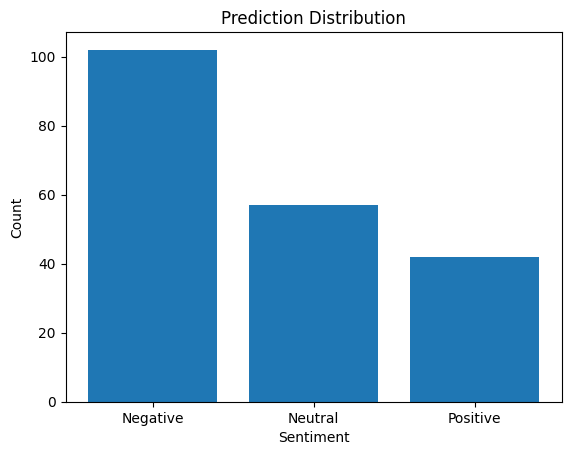

In [24]:
counts = {0: 0, 1: 0, 2: 0}

for p in preds:
    counts[p] += 1

neg = counts[0]
net = counts[1]
pos = counts[2]

import matplotlib.pyplot as plt

labels = ["Negative", "Neutral", "Positive"]
values = [neg, net, pos]

plt.bar(labels, values)

plt.title("Prediction Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# 8. Evaluate Performance

In [25]:
preds_labeled = [labels[x] for x in preds]
trues_labeled = [labels[x] for x in trues]

print(preds_labeled)
print(trues_labeled)

['Neutral', 'Negative', 'Negative', 'Negative', 'Neutral', 'Positive', 'Positive', 'Positive', 'Positive', 'Neutral', 'Negative', 'Negative', 'Negative', 'Neutral', 'Neutral', 'Neutral', 'Negative', 'Neutral', 'Neutral', 'Negative', 'Negative', 'Negative', 'Neutral', 'Positive', 'Neutral', 'Negative', 'Negative', 'Neutral', 'Positive', 'Neutral', 'Neutral', 'Positive', 'Negative', 'Neutral', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Neutral', 'Negative', 'Positive', 'Negative', 'Negative', 'Negative', 'Neutral', 'Neutral', 'Negative', 'Negative', 'Positive', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Neutral', 'Negative', 'Negative', 'Neutral', 'Positive', 'Negative', 'Neutral', 'Negative', 'Neutral', 'Negative', 'Neutral', 'Neutral', 'Negative', 'Negative', 'Neutral', 'Negative', 'Neutral', 'Positive', 'Positive', 'Neutral', 'Negative', 'Neutral', 'Neutral

## 8.1 Confusion Matrix

In [26]:
cm = confusion_matrix(trues, preds)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(cm_df)

          Negative  Neutral  Positive
Negative        85       20         4
Neutral         12       33         8
Positive         5        4        30


## 8.2 Accuracy

In [27]:
correct = 0

for i in range(len(preds)):
    if preds[i] == trues[i]:
        correct += 1

accuracy = correct / len(preds)

print("Accuracy:", accuracy)

Accuracy: 0.736318407960199


## 8.3 Precision, Recall

In [28]:
results = {}

for cls in labels:
    tp = 0
    fp = 0
    fn = 0

    for i in range(len(trues_labeled)):
        if preds_labeled[i] == cls and trues_labeled[i] == cls:
            tp += 1
        elif preds_labeled[i] == cls and trues_labeled[i] != cls:
            fp += 1
        elif preds_labeled[i] != cls and trues_labeled[i] == cls:
            fn += 1

    # avoid division by zero
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    results[cls] = {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

for k in results.keys():
    print(k, ":", results[k])

Negative : {'precision': 0.8333333333333334, 'recall': 0.7798165137614679, 'f1': 0.8056872037914692}
Neutral : {'precision': 0.5789473684210527, 'recall': 0.6226415094339622, 'f1': 0.6}
Positive : {'precision': 0.7142857142857143, 'recall': 0.7692307692307693, 'f1': 0.7407407407407408}


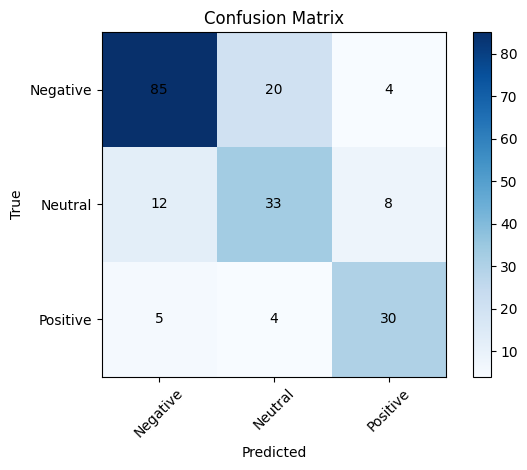

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# create label index mapping
label_to_idx = {label: i for i, label in enumerate(labels)}

# initialize confusion matrix
cm = np.zeros((len(labels), len(labels)), dtype=int)

# fill confusion matrix
for t, p in zip(trues_labeled, preds_labeled):
    i = label_to_idx[t]
    j = label_to_idx[p]
    cm[i][j] += 1

# plot
plt.figure()
plt.imshow(cm, cmap="Blues")  # <-- blue gradient
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# ticks
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

# annotate values
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# Citations

@misc {wilson_wongso_2023,
    author       = { {Wilson Wongso} },
    title        = { indonesian-roberta-base-sentiment-classifier (Revision e402e46) },
    year         = 2023,
    url          = { https://huggingface.co/w11wo/indonesian-roberta-base-sentiment-classifier },
    doi          = { 10.57967/hf/0644 },
    publisher    = { Hugging Face }
}